FLAIR Shape: (240, 240, 155)
T1 Shape: (240, 240, 155)
T1ce Shape: (240, 240, 155)
T2 Shape: (240, 240, 155)
SEG Shape: (240, 240, 155)


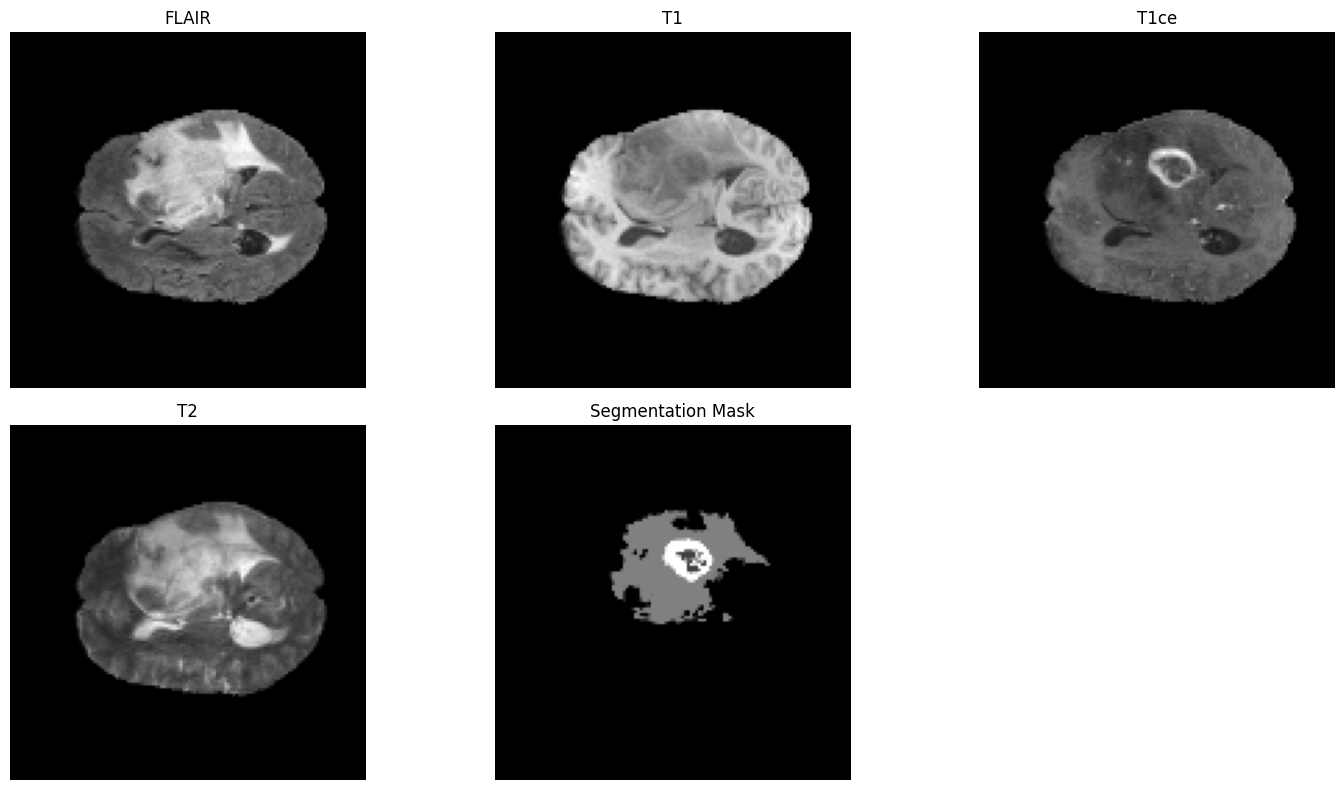

In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

# -------------------------------
# STEP 1: Patient folder path
# -------------------------------

patient_path = "../dataset/BraTs2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/"

# Change if your folder structure is slightly different

# -------------------------------
# STEP 2: File paths
# -------------------------------

flair_path = os.path.join(patient_path, "BraTS20_Training_001_flair.nii")
t1_path = os.path.join(patient_path, "BraTS20_Training_001_t1.nii")
t1ce_path = os.path.join(patient_path, "BraTS20_Training_001_t1ce.nii")
t2_path = os.path.join(patient_path, "BraTS20_Training_001_t2.nii")
seg_path = os.path.join(patient_path, "BraTS20_Training_001_seg.nii")

# -------------------------------
# STEP 3: Load .nii files
# -------------------------------

flair = nib.load(flair_path).get_fdata()
t1 = nib.load(t1_path).get_fdata()
t1ce = nib.load(t1ce_path).get_fdata()
t2 = nib.load(t2_path).get_fdata()
seg = nib.load(seg_path).get_fdata()

# -------------------------------
# STEP 4: Check shapes
# -------------------------------

print("FLAIR Shape:", flair.shape)
print("T1 Shape:", t1.shape)
print("T1ce Shape:", t1ce.shape)
print("T2 Shape:", t2.shape)
print("SEG Shape:", seg.shape)

# Expected:
# (240, 240, 155)

# -------------------------------
# STEP 5: Select one useful slice
# -------------------------------

slice_num = 75

flair_slice = flair[:, :, slice_num]
t1_slice = t1[:, :, slice_num]
t1ce_slice = t1ce[:, :, slice_num]
t2_slice = t2[:, :, slice_num]
seg_slice = seg[:, :, slice_num]

# -------------------------------
# STEP 6: Resize to 128x128
# -------------------------------

size = 128

flair_slice = cv2.resize(flair_slice, (size, size))
t1_slice = cv2.resize(t1_slice, (size, size))
t1ce_slice = cv2.resize(t1ce_slice, (size, size))
t2_slice = cv2.resize(t2_slice, (size, size))
seg_slice = cv2.resize(seg_slice, (size, size))

# -------------------------------
# STEP 7: Display all modalities
# -------------------------------

plt.figure(figsize=(15, 8))

titles = ["FLAIR", "T1", "T1ce", "T2", "Segmentation Mask"]
images = [flair_slice, t1_slice, t1ce_slice, t2_slice, seg_slice]

for i in range(5):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [2]:
!pip install opencv-python

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/fd/55/b3b49a1b97aabcfbbd6c7326df9cb0b6fa0c0aefa8e89d500939e04aa229/opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for numpy>=2 from https://files.pythonhosted.org/packages/cf/c5/9fcb7e0e69cef59cf10c746b84f7d58b08bc66a6b7d459783c5a4f6101a6/numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 1.1 MB/s eta 0:00:0000:0100:02
Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages